In [1]:
# This cell installs all necessary libraries for the notebook.
# Note: GPy has been removed due to installation issues and replaced with scikit-learn's GPR.
!pip install pandas numpy openpyxl scikit-learn matplotlib seaborn xgboost shap --quiet
print("All libraries installed successfully.")

All libraries installed successfully.


In [2]:
# CELL 2: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import math
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')

# Set plot style and SHAP visualization settings
sns.set_theme(style="whitegrid")
shap.initjs()


In [3]:
# CELL 2: load
df_raw = pd.read_excel("Zn.xlsx")
print("Raw shape:", df_raw.shape)
display(df_raw)


Raw shape: (13, 6)


,Catalyst_Type,Temperature,Time,MFI,Crossover_Frequency,Complex_Viscosity
0,ZN-HDPE,0,0,0.23,3.0,90800.0
1,ZN-HDPE,170,10,0.32,9.0,73235.0
2,ZN-HDPE,170,20,1.20,12.0,64712.0
3,ZN-HDPE,170,30,2.50,61.0,18132.0
4,ZN-HDPE,170,60,5.40,NaN,6853.4
5,ZN-HDPE,170,120,11.20,NaN,2931.8
6,ZN-HDPE,170,240,23.80,NaN,NaN
7,ZN-HDPE,210,10,0.60,3.2,121780.0
8,ZN-HDPE,210,20,0.80,2.8,135020.0
9,ZN-HDPE,210,30,2.30,8.5,53379.0


In [4]:
# Cell 2
df_raw = pd.read_excel("Zn.xlsx")
# drop crossover if present
if "Crossover_Frequency" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Crossover_Frequency"])
# ensure numeric conversion
for c in ["Temperature", "Time", "MFI", "Complex_Viscosity"]:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors="coerce")
print("Original rows:", len(df_raw))
display(df_raw)


Original rows: 13


,Catalyst_Type,Temperature,Time,MFI,Complex_Viscosity
0,ZN-HDPE,0,0,0.23,90800.0
1,ZN-HDPE,170,10,0.32,73235.0
2,ZN-HDPE,170,20,1.20,64712.0
3,ZN-HDPE,170,30,2.50,18132.0
4,ZN-HDPE,170,60,5.40,6853.4
5,ZN-HDPE,170,120,11.20,2931.8
6,ZN-HDPE,170,240,23.80,NaN
7,ZN-HDPE,210,10,0.60,121780.0
8,ZN-HDPE,210,20,0.80,135020.0
9,ZN-HDPE,210,30,2.30,53379.0


In [5]:
# Cell 3
df_mfi = df_raw[df_raw["MFI"].notna()].copy().reset_index(drop=True)
df_vis = df_raw[df_raw["Complex_Viscosity"].notna()].copy().reset_index(drop=True)

print("Rows with MFI available:", len(df_mfi))
print("Rows with viscosity available:", len(df_vis))

display(df_mfi)
display(df_vis)


Rows with MFI available: 13
Rows with viscosity available: 11


,Catalyst_Type,Temperature,Time,MFI,Complex_Viscosity
0,ZN-HDPE,0,0,0.23,90800.0
1,ZN-HDPE,170,10,0.32,73235.0
2,ZN-HDPE,170,20,1.20,64712.0
3,ZN-HDPE,170,30,2.50,18132.0
4,ZN-HDPE,170,60,5.40,6853.4
5,ZN-HDPE,170,120,11.20,2931.8
6,ZN-HDPE,170,240,23.80,NaN
7,ZN-HDPE,210,10,0.60,121780.0
8,ZN-HDPE,210,20,0.80,135020.0
9,ZN-HDPE,210,30,2.30,53379.0


,Catalyst_Type,Temperature,Time,MFI,Complex_Viscosity
0,ZN-HDPE,0,0,0.23,90800.0
1,ZN-HDPE,170,10,0.32,73235.0
2,ZN-HDPE,170,20,1.20,64712.0
3,ZN-HDPE,170,30,2.50,18132.0
4,ZN-HDPE,170,60,5.40,6853.4
5,ZN-HDPE,170,120,11.20,2931.8
6,ZN-HDPE,210,10,0.60,121780.0
7,ZN-HDPE,210,20,0.80,135020.0
8,ZN-HDPE,210,30,2.30,53379.0
9,ZN-HDPE,210,60,4.80,34835.0


In [71]:
# Cell 4

# prepare inputs
X_mfi = df_mfi[["Temperature", "Time"]].values.astype(float)
y_mfi = np.log10(df_mfi["MFI"].values.astype(float))

# scale inputs
scaler_X = StandardScaler().fit(X_mfi)
X_mfi_s = scaler_X.transform(X_mfi)

# kernel and GPR (small restart for stability)
"""KERNAL PROBLEM"""
gpr_mfi = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=6, random_state=0)"""
gpr_mfi.fit(X_mfi_s, y_mfi)

print("GPR kernel after fit:", gpr_mfi.kernel_)
# compute in-sample residuals to estimate MFI noise scale
y_pred_mfi, y_std_mfi = gpr_mfi.predict(X_mfi_s, return_std=True)
resid_mfi = y_mfi - y_pred_mfi
resid_mfi_std = max(1e-3, np.std(resid_mfi))
print("Empirical residual std (log10 MFI):", resid_mfi_std)


GPR kernel after fit: 1.15**2 * RBF(length_scale=[1e+03, 0.398]) + WhiteKernel(noise_level=0.0322)
Empirical residual std (log10 MFI): 0.08814388449937946


In [72]:
# Cell 5
# Build prediction of MFI for rows used in viscosity fit: if measured MFI exists use it; else use GP mean
def predict_mfi_row(row):
    if not np.isnan(row.get("MFI", np.nan)):
        return float(row["MFI"])
    Xr = np.array([[row["Temperature"], row["Time"]]])
    Xr_s = scaler_X.transform(Xr)
    pred_log, _ = gpr_mfi.predict(Xr_s, return_std=True)
    return 10.0 ** pred_log[0]

df_vis["MFI_pred"] = df_vis.apply(predict_mfi_row, axis=1)
# prepare arrays
log10M = np.log10(df_vis["MFI_pred"].values)
invT = 1.0 / (df_vis["Temperature"].values + 273.15)
y_vis_log10 = np.log10(df_vis["Complex_Viscosity"].values)

# wrapper: parameters = [log10C, s_alpha (we'll param alpha = exp(s_alpha)), Ea_vis]
def vis_wrapper(x_flat, log10C, s_alpha, Ea_vis):
    N = x_flat.size // 2
    log10M_arr = x_flat[:N]
    invT_arr = x_flat[N:2*N]
    alpha = np.exp(s_alpha)  # ensures alpha > 0
    return log10C - alpha * log10M_arr + (Ea_vis * invT_arr) / np.log(10.0)

x_flat_vis = np.concatenate([log10M, invT])
p0 = [5.0, np.log(3.0), 8000.0]  # initial: log10C~1e5, alpha~3, Ea
bounds_lower = [0.0, np.log(0.01), 0.0]
bounds_upper = [10.0, np.log(20.0), 5e4]

popt_vis, pcov_vis = curve_fit(vis_wrapper, x_flat_vis, y_vis_log10, p0=p0, bounds=(bounds_lower, bounds_upper), maxfev=80000)
log10C_fit, s_alpha_fit, Ea_vis_fit = popt_vis
alpha_fit = float(np.exp(s_alpha_fit))
print("Fitted viscosity params: log10C, alpha, Ea_vis =", np.round([log10C_fit, alpha_fit, Ea_vis_fit],6))
# estimate resid std in log10
y_pred_vis_log10 = vis_wrapper(x_flat_vis, *popt_vis)
resid_vis_std = max(1e-4, np.std(y_vis_log10 - y_pred_vis_log10))
print("Visc residual std (log10):", resid_vis_std)


Fitted viscosity params: log10C, alpha, Ea_vis = [4.792271 0.471114 0.      ]
Visc residual std (log10): 0.20703290495554558


In [73]:
# Cell 6
N_SYN = 3000
# integer sampling
syn_T = rng.integers(160, 231, size=N_SYN)      # inclusive 160..230
syn_time = rng.integers(10, 241, size=N_SYN)    # inclusive 10..240

# GP predictive mean + std at new points
Xsyn = np.vstack([syn_T, syn_time]).T
Xsyn_s = scaler_X.transform(Xsyn)
logM_mean, logM_std = gpr_mfi.predict(Xsyn_s, return_std=True)

# Ensure a minimum uncertainty (to avoid zero-stdev extrapolation)
min_logM_std = max(0.03, 0.05 * np.std(y_mfi))  # ~3e-2 log units or 5% of observed log-MFI spread
logM_std = np.maximum(logM_std, min_logM_std)

# sample log10(MFI) (one draw per synthetic point)
logM_samps = logM_mean + rng.normal(0.0, logM_std)

# convert to MFI and clip to realistic bounds from observed data (conservative)
mfi_min_obs = float(df_mfi["MFI"].min())
mfi_max_obs = float(df_mfi["MFI"].max())
mfi_lower = max(1e-3, 0.5 * mfi_min_obs)
mfi_upper = 3.0 * mfi_max_obs
syn_mfi = 10.0 ** logM_samps
syn_mfi = np.clip(syn_mfi, mfi_lower, mfi_upper)

# compute viscosity from fitted model
T_K_syn = syn_T + 273.15
invT_syn = 1.0 / T_K_syn
log10M_syn = np.log10(syn_mfi)
x_flat_syn = np.concatenate([log10M_syn, invT_syn])
log10_eta_mean = vis_wrapper(x_flat_syn, *popt_vis)

# add observational noise in log10 space
log10_eta_noisy = log10_eta_mean + rng.normal(0.0, resid_vis_std, size=N_SYN)
eta_syn = 10.0 ** log10_eta_noisy

# clip viscosity to conservative bounds based on observed real range
if len(df_vis) > 0:
    vis_min_obs = float(df_vis["Complex_Viscosity"].min())
    vis_max_obs = float(df_vis["Complex_Viscosity"].max())
else:
    vis_min_obs, vis_max_obs = 1e4, 2e5

vis_lower = max(1e2, 0.2 * vis_min_obs)
vis_upper = 5.0 * vis_max_obs
eta_syn = np.clip(eta_syn, vis_lower, vis_upper)

synthetic_df = pd.DataFrame({
    "Catalyst_Type": "ZN-HDPE",
    "Temperature": syn_T.astype(int),
    "Time": syn_time.astype(int),
    "MFI": syn_mfi,
    "Complex_Viscosity": eta_syn
})

# Save
synthetic_df.to_csv("synthetic_viscosity_3000_ZN_conditional.csv", index=False)
print("Saved synthetic_viscosity_3000_ZN_conditional.csv  (shape: {})".format(synthetic_df.shape))
display(synthetic_df.head(30))


Saved synthetic_viscosity_3000_ZN_conditional.csv  (shape: (3000, 5))


,Catalyst_Type,Temperature,Time,MFI,Complex_Viscosity
0,ZN-HDPE,194,225,26.476210,11215.897850
1,ZN-HDPE,179,153,1.593402,70229.739737
2,ZN-HDPE,190,65,6.022803,32902.550895
3,ZN-HDPE,210,39,6.237660,38971.244728
4,ZN-HDPE,172,68,6.038156,29529.881559
5,ZN-HDPE,160,216,3.947456,28816.877437
6,ZN-HDPE,185,229,13.145544,8946.148288
7,ZN-HDPE,219,216,5.170697,12488.587384
8,ZN-HDPE,181,218,6.910112,28214.130305
9,ZN-HDPE,197,14,1.312266,54868.041234


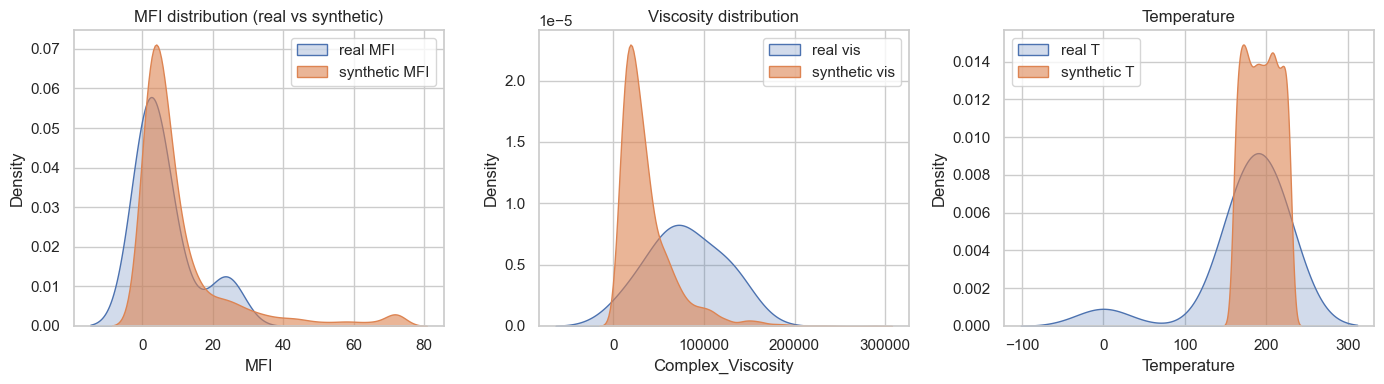

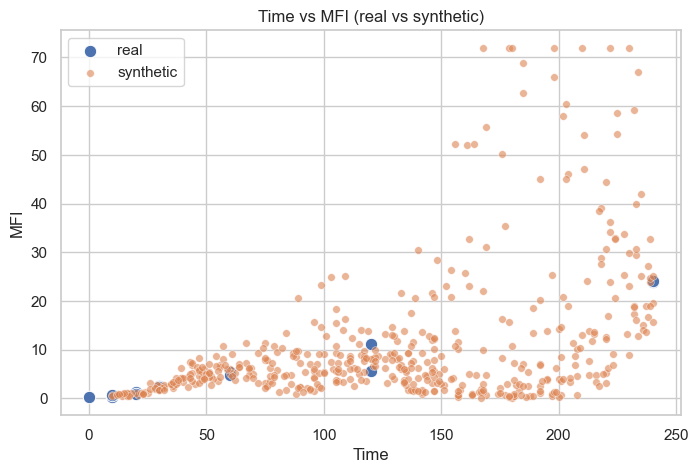

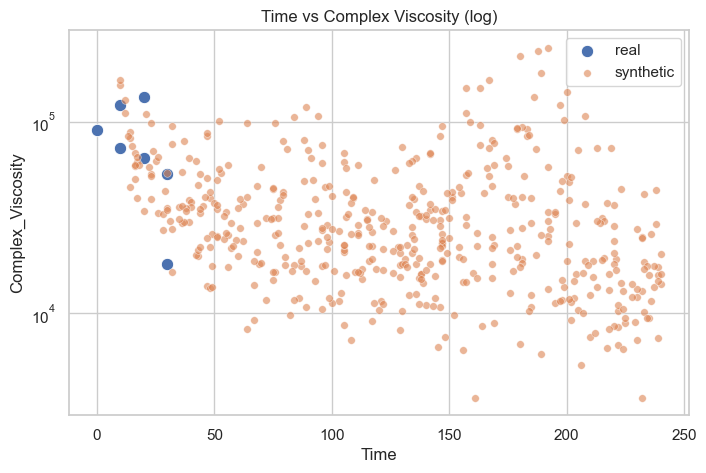

In [74]:
# Cell 7
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
sns.kdeplot(df_mfi["MFI"], label="real MFI", fill=True)
sns.kdeplot(synthetic_df["MFI"], label="synthetic MFI", fill=True, alpha=0.6)
plt.legend(); plt.title("MFI distribution (real vs synthetic)")

plt.subplot(1,3,2)
if len(df_vis)>0:
    sns.kdeplot(df_vis["Complex_Viscosity"], label="real vis", fill=True)
sns.kdeplot(synthetic_df["Complex_Viscosity"], label="synthetic vis", fill=True, alpha=0.6)
plt.legend(); plt.title("Viscosity distribution")

plt.subplot(1,3,3)
sns.kdeplot(df_mfi["Temperature"], label="real T", fill=True)
sns.kdeplot(synthetic_df["Temperature"], label="synthetic T", fill=True, alpha=0.6)
plt.legend(); plt.title("Temperature")
plt.tight_layout()
plt.show()

# scatter
sample_syn = synthetic_df.sample(min(500, len(synthetic_df)), random_state=1)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_mfi["Time"], y=df_mfi["MFI"], label="real", s=80)
sns.scatterplot(x=sample_syn["Time"], y=sample_syn["MFI"], label="synthetic", alpha=0.6, s=30)
plt.legend(); plt.title("Time vs MFI (real vs synthetic)")
plt.show()

plt.figure(figsize=(8,5))
if len(df_vis)>0:
    sns.scatterplot(x=df_vis["Time"], y=df_vis["Complex_Viscosity"], label="real", s=80)
sns.scatterplot(x=sample_syn["Time"], y=sample_syn["Complex_Viscosity"], label="synthetic", alpha=0.6, s=30)
plt.yscale("log"); plt.legend(); plt.title("Time vs Complex Viscosity (log)")
plt.show()
